In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
try:
    df = pd.read_csv('raw/smoke.csv', header=[0, 1], encoding='cp949')
except:
    df = pd.read_csv('raw/smoke.csv', header=[0, 1], encoding='euc-kr')

male_row = df[(df[('성별(1)', '성별(1)')] == '남자') & (df[('특성별(2)', '특성별(2)')] == '19세이상')]
female_row = df[(df[('성별(1)', '성별(1)')] == '여자') & (df[('특성별(2)', '특성별(2)')] == '19세이상')]

years, male_rates, female_rates = [], [], []

for col in df.columns:
    year = col[0]
    sub_col = col[1]
    if '분율 (%)' in sub_col and year.isdigit():
        years.append(int(year))
        m_val = str(male_row[col].values[0]).replace('*', '').strip()
        f_val = str(female_row[col].values[0]).replace('*', '').strip()
        male_rates.append(float(m_val))
        female_rates.append(float(f_val))

clean_df = pd.DataFrame({
    'year': years,
    'male_rate': male_rates,
    'female_rate': female_rates
}).sort_values('year')

def get_price(year):
    if year < 2005: return 2000
    elif year < 2015: return 2500
    else: return 4500

clean_df['price'] = clean_df['year'].apply(get_price)

X = clean_df[['year', 'price']]
y = clean_df[['male_rate', 'female_rate']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

print("--- 선형 회귀 학습 완료 (2005~2024 데이터) ---")

future_year = 2026
test_prices = [4500, 8000, 10000, 12000]

print(f"\n[연도: {future_year}년 시나리오별 예측]")
print("-" * 45)
for p in test_prices:
    future_X = pd.DataFrame([[future_year, p]], columns=['year', 'price'])
    future_scaled = scaler.transform(future_X)
    pred = model.predict(future_scaled)
    
    m_pred = max(0, pred[0][0])
    f_pred = max(0, pred[0][1])
    
    print(f"담배값 {p:5d}원 -> 남성: {m_pred:5.2f}% | 여성: {f_pred:5.2f}%")

--- 선형 회귀 학습 완료 (2005~2024 데이터) ---

[연도: 2026년 시나리오별 예측]
---------------------------------------------
담배값  4500원 -> 남성: 26.73% | 여성:  4.76%
담배값  8000원 -> 남성: 23.90% | 여성:  4.84%
담배값 10000원 -> 남성: 22.28% | 여성:  4.89%
담배값 12000원 -> 남성: 20.67% | 여성:  4.93%


In [3]:
smoke_money = 4500

scenario_title = f"{smoke_money:,}원 인상" if smoke_money > 4500 else "4,500원 동결"

future_years = [2025, 2026]
future_prices = [4500, smoke_money]

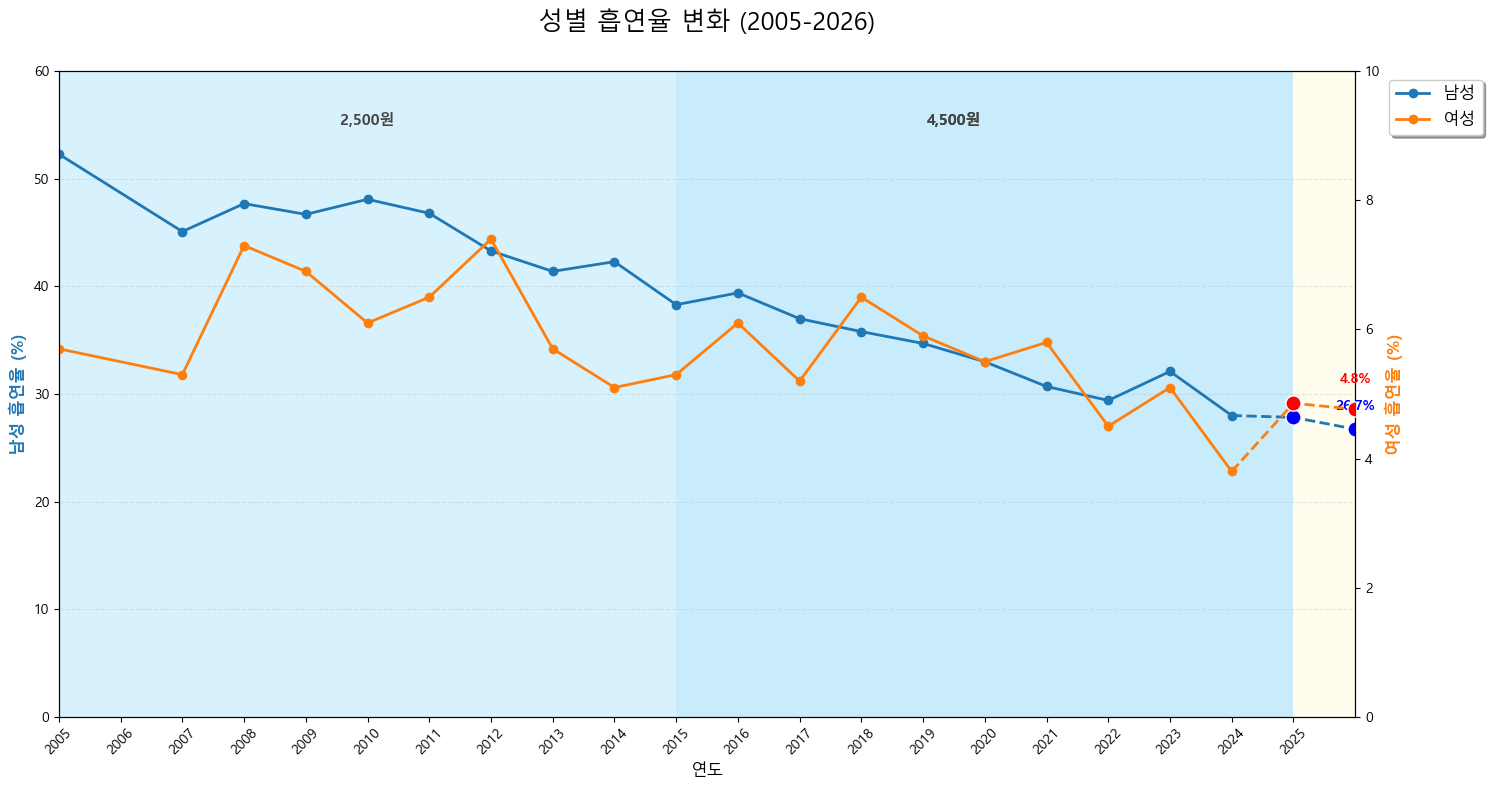

In [4]:
future_df = pd.DataFrame({'year': future_years, 'price': future_prices})
future_scaled = scaler.transform(future_df)
future_preds = model.predict(future_scaled)

col_m = 'male_rate'
col_f = 'female_rate'
fig, ax1 = plt.subplots(figsize=(15, 8))

price_regions = [
    (2005, 2015, 2500, '#81D4FA'),
    (2015, 2025, 4500, '#4FC3F7'),
    (2025, 2026, smoke_money, '#FFF9C4'),
]

for i, (start, end, price, color) in enumerate(price_regions):
    ax1.axvspan(start, end, facecolor=color, alpha=0.3)
    
    if price == 2500:
        text_x = 2010 
    elif price == 4500:
        text_x = 2019.5
    elif price == smoke_money:
        text_x = 2026
    else:
        text_x = (start + end) / 2

    ax1.text(text_x, 55, f'{price:,}원', ha='center', fontweight='bold', 
             color='#444444', fontsize=11, zorder=10)

last_year = clean_df['year'].iloc[-1]
plot_years = [last_year] + future_years
m_vals = [clean_df[col_m].iloc[-1]] + list(future_preds[:, 0])
f_vals = [clean_df[col_f].iloc[-1]] + list(future_preds[:, 1])

color_m = '#1f77b4'
line_m, = ax1.plot(clean_df['year'], clean_df[col_m], marker='o', label='남성', color=color_m, linewidth=2)
ax1.plot(plot_years, m_vals, color=color_m, linestyle='--', linewidth=2, zorder=4)
ax1.scatter(future_years, future_preds[:, 0], color='blue', s=120, zorder=5, edgecolors='white')

ax1.set_ylabel('남성 흡연율 (%)', color=color_m, fontsize=12, fontweight='bold')
ax1.set_ylim(0, 60)

ax2 = ax1.twinx()
color_f = '#ff7f0e'
line_f, = ax2.plot(clean_df['year'], clean_df[col_f], marker='o', label='여성', color=color_f, linewidth=2)
ax2.plot(plot_years, f_vals, color=color_f, linestyle='--', linewidth=2, zorder=4)
ax2.scatter(future_years, future_preds[:, 1], color='red', s=120, zorder=5, edgecolors='white')

ax2.set_ylabel('여성 흡연율 (%)', color=color_f, fontsize=12, fontweight='bold')
ax2.set_ylim(0, 10)

ax1.text(2026, future_preds[1, 0] + 1.8, f'{future_preds[1, 0]:.1f}%', ha='center', color='blue', fontweight='bold')
ax2.text(2026, future_preds[1, 1] + 0.4, f'{future_preds[1, 1]:.1f}%', ha='center', color='red', fontweight='bold')

plt.title('성별 흡연율 변화 (2005-2026)', fontsize=18, pad=30)
ax1.set_xlabel('연도', fontsize=12)
ax1.set_xlim(2005, 2026)
ax1.set_xticks(np.arange(2005, 2026, 1))
plt.setp(ax1.get_xticklabels(), rotation=45)

ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

lines = [line_m, line_f]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

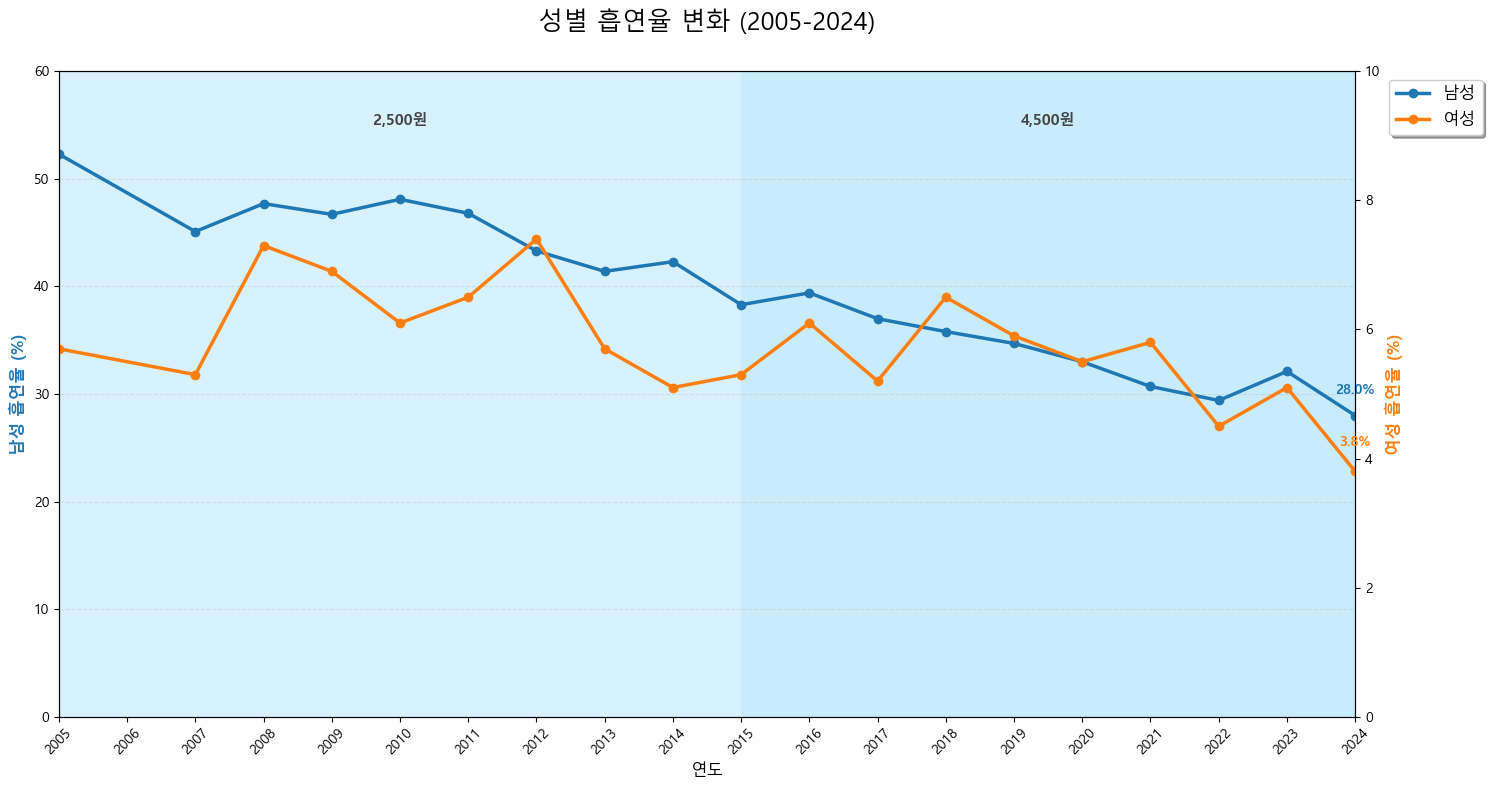

In [5]:
fig, ax1 = plt.subplots(figsize=(15, 8))

price_regions_24 = [
    (2005, 2015, 2500, '#81D4FA'),
    (2015, 2024, 4500, '#4FC3F7'),
]

for start, end, price, color in price_regions_24:
    display_end = min(end, 2024)
    ax1.axvspan(start, display_end, facecolor=color, alpha=0.3)
    
    if price == 2500:
        text_x = 2010
    else:
        text_x = 2019.5
        
    ax1.text(text_x, 55, f'{price:,}원', ha='center', fontweight='bold', 
             color='#444444', fontsize=11, zorder=10)

color_m = '#1f77b4'
line_m, = ax1.plot(clean_df['year'], clean_df[col_m], marker='o', 
                   label='남성', color=color_m, linewidth=2.5)

ax1.set_ylabel('남성 흡연율 (%)', color=color_m, fontsize=12, fontweight='bold')
ax1.set_ylim(0, 60)

ax2 = ax1.twinx()
color_f = '#ff7f0e'
line_f, = ax2.plot(clean_df['year'], clean_df[col_f], marker='o', 
                   label='여성', color=color_f, linewidth=2.5)

ax2.set_ylabel('여성 흡연율 (%)', color=color_f, fontsize=12, fontweight='bold')
ax2.set_ylim(0, 10)

last_m = clean_df[col_m].iloc[-1]
last_f = clean_df[col_f].iloc[-1]
ax1.text(2024, last_m + 2, f'{last_m:.1f}%', ha='center', color=color_m, fontweight='bold')
ax2.text(2024, last_f + 0.4, f'{last_f:.1f}%', ha='center', color=color_f, fontweight='bold')

plt.title('성별 흡연율 변화 (2005-2024)', fontsize=18, pad=30)
ax1.set_xlabel('연도', fontsize=12)
ax1.set_xlim(2005, 2024)
ax1.set_xticks(np.arange(2005, 2025, 1))
plt.setp(ax1.get_xticklabels(), rotation=45)

ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

lines = [line_m, line_f]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(1.02, 1), 
           fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

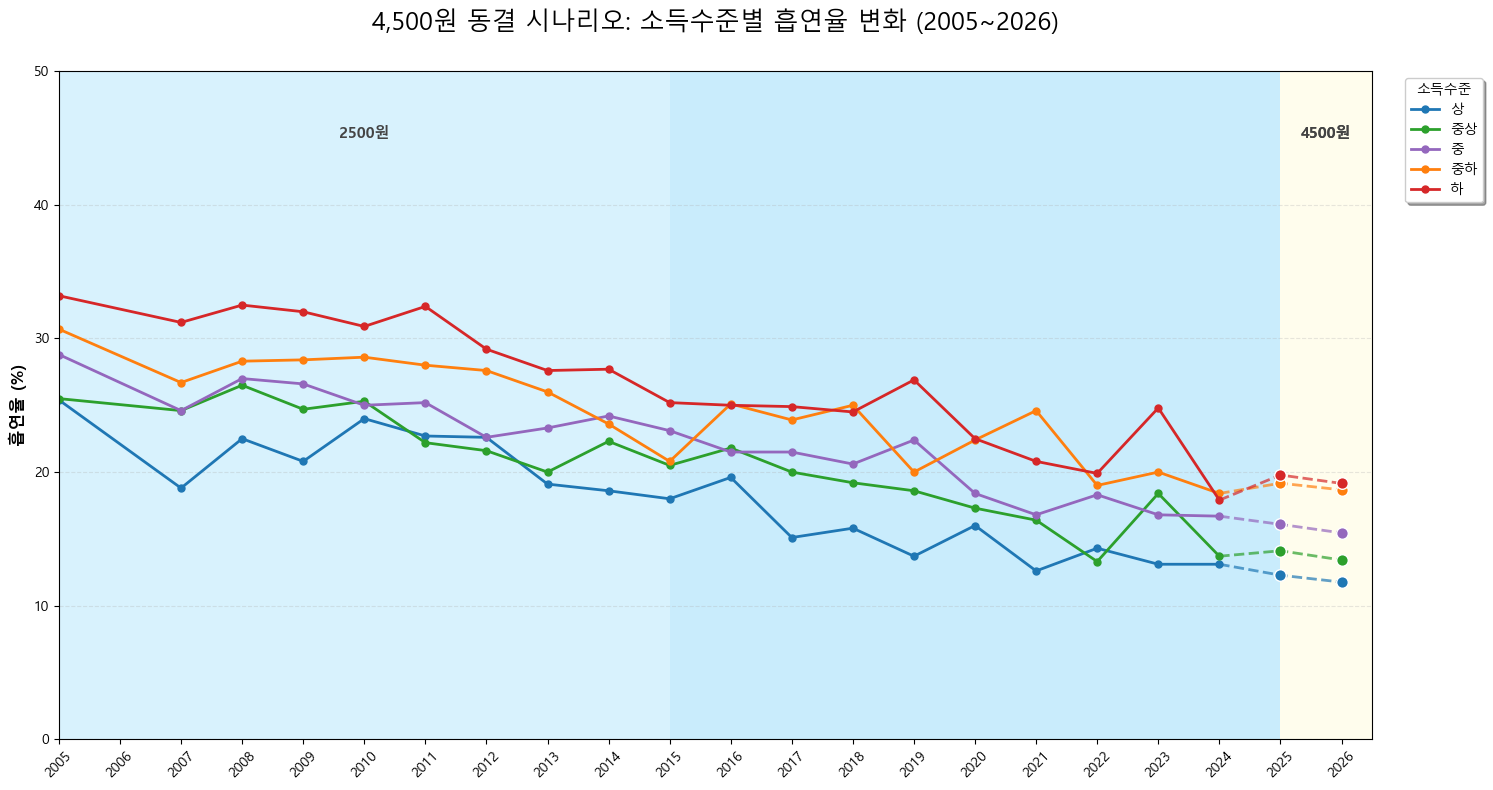

In [6]:
income_levels = ['상', '중상', '중', '중하', '하']
income_rows = {}
for level in income_levels:
    income_rows[level] = df[df[('특성별(2)', '특성별(2)')] == level]

for level in income_levels:
    level_rates = []
    for col in df.columns:
        year = col[0]
        sub_col = col[1]
        if '분율 (%)' in sub_col and year.isdigit():
            val = str(income_rows[level][col].values[0]).replace('*', '').strip()
            level_rates.append(float(val) if val and val != 'nan' else np.nan)
    
    clean_df[level] = level_rates

income_levels = ['상', '중상', '중', '중하', '하']
colors = ['#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e', '#d62728']

future_df = pd.DataFrame({'year': future_years, 'price': future_prices})
future_scaled = scaler.transform(future_df)

fig, ax1 = plt.subplots(figsize=(15, 8))

price_regions = [
    (2005, 2015, 2500, '#81D4FA'),
    (2015, 2025, 4500, '#4FC3F7'), 
    (2025, 2027, smoke_money, '#FFF9C4')  
]

for start, end, price, bg_color in price_regions:
    ax1.axvspan(start, end, facecolor=bg_color, alpha=0.3)
    if price == smoke_money:
        ax1.text(2025.75, 45, f'{price}원', ha='center', fontweight='bold', color='#444444', fontsize=11)
    else:
        ax1.text((start + end) / 2, 45, f'{price}원', ha='center', fontweight='bold', color='#444444', fontsize=11)

last_year = clean_df['year'].iloc[-1]
lines = []

for level, line_color in zip(income_levels, colors):
    y_vals = clean_df[level]
    model_lvl = LinearRegression().fit(X_scaled, y_vals)
    preds = np.maximum(0, model_lvl.predict(future_scaled))
    
    plot_years = [last_year] + future_years
    plot_values = [clean_df[level].iloc[-1]] + list(preds)
    
    line, = ax1.plot(clean_df['year'], clean_df[level], marker='o', label=level, 
                     color=line_color, linewidth=2, markersize=5)
    lines.append(line)
    
    ax1.plot(plot_years, plot_values, color=line_color, linestyle='--', linewidth=2, alpha=0.7)
    
    ax1.scatter(future_years, preds, color=line_color, s=70, zorder=5, edgecolors='white')

plt.title(scenario_title + ' 시나리오: 소득수준별 흡연율 변화 (2005~2026)', fontsize=18, pad=30)
ax1.set_xlim(2005, 2026.5)
ax1.set_xticks(np.arange(2005, 2027, 1))
plt.setp(ax1.get_xticklabels(), rotation=45)

ax1.set_ylim(0, 50)
ax1.set_ylabel('흡연율 (%)', fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

ax1.legend(lines, income_levels, title='소득수준', loc='upper left', bbox_to_anchor=(1.02, 1), 
           frameon=True, shadow=True)

plt.tight_layout()
plt.show()

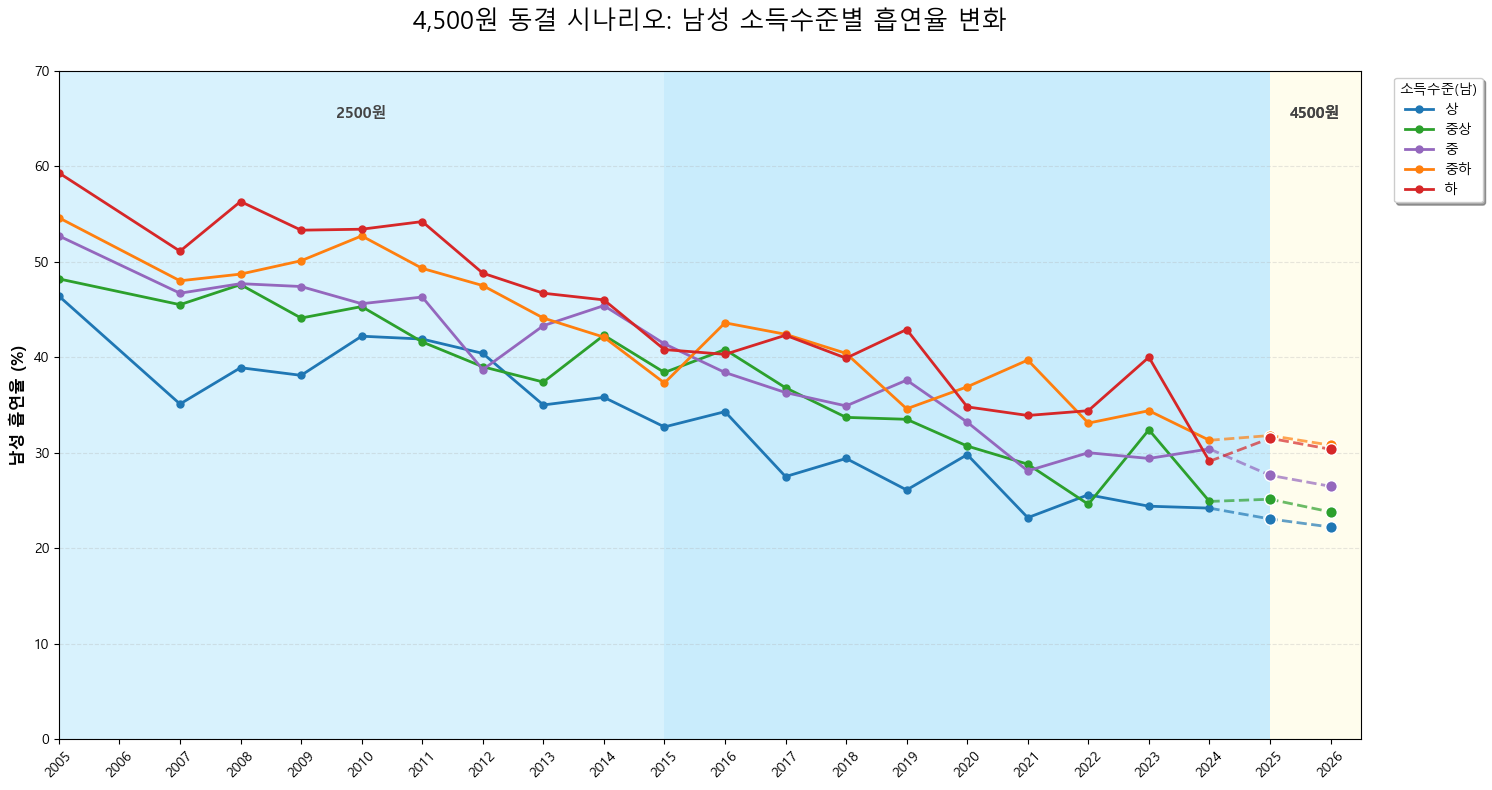

In [7]:
income_levels = ['상', '중상', '중', '중하', '하']
colors = ['#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e', '#d62728']

male_income_df = pd.DataFrame({'year': clean_df['year']})

for level in income_levels:
    m_income_row = df[(df[('성별(1)', '성별(1)')] == '남자') & (df[('특성별(2)', '특성별(2)')] == level)]
    
    m_level_rates = []
    for col in df.columns:
        year = col[0]
        sub_col = col[1]
        if '분율 (%)' in sub_col and year.isdigit():
            val = str(m_income_row[col].values[0]).replace('*', '').strip()
            m_level_rates.append(float(val) if val and val != 'nan' else np.nan)
    
    male_income_df[level] = m_level_rates

fig, ax1 = plt.subplots(figsize=(15, 8))

for start, end, price, bg_color in price_regions:
    ax1.axvspan(start, end, facecolor=bg_color, alpha=0.3)
    if price == smoke_money:
        ax1.text(2025.75, 65, f'{price}원', ha='center', fontweight='bold', color='#444444', fontsize=11)
    else:
        ax1.text((start + end) / 2, 65, f'{price}원', ha='center', fontweight='bold', color='#444444', fontsize=11)

last_year = male_income_df['year'].iloc[-1]
lines = []

for level, line_color in zip(income_levels, colors):
    y_vals = male_income_df[level].dropna()
    current_X_scaled = X_scaled[:len(y_vals)] 
    
    model_m_lvl = LinearRegression().fit(current_X_scaled, y_vals)
    preds = np.maximum(0, model_m_lvl.predict(future_scaled))
    
    plot_years = [last_year] + future_years
    plot_values = [male_income_df[level].iloc[-1]] + list(preds)

    line, = ax1.plot(male_income_df['year'], male_income_df[level], marker='o', label=level, 
                     color=line_color, linewidth=2, markersize=5)
    lines.append(line)
    ax1.plot(plot_years, plot_values, color=line_color, linestyle='--', linewidth=2, alpha=0.7)

    ax1.scatter(future_years, preds, color=line_color, s=70, zorder=5, edgecolors='white')

plt.title(scenario_title + ' 시나리오: 남성 소득수준별 흡연율 변화', fontsize=18, pad=30)
ax1.set_xlim(2005, 2026.5)
ax1.set_xticks(np.arange(2005, 2027, 1))
plt.setp(ax1.get_xticklabels(), rotation=45)

ax1.set_ylim(0, 70)
ax1.set_ylabel('남성 흡연율 (%)', fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

ax1.legend(lines, income_levels, title='소득수준(남)', loc='upper left', bbox_to_anchor=(1.02, 1), 
           frameon=True, shadow=True)

plt.tight_layout()
plt.show()

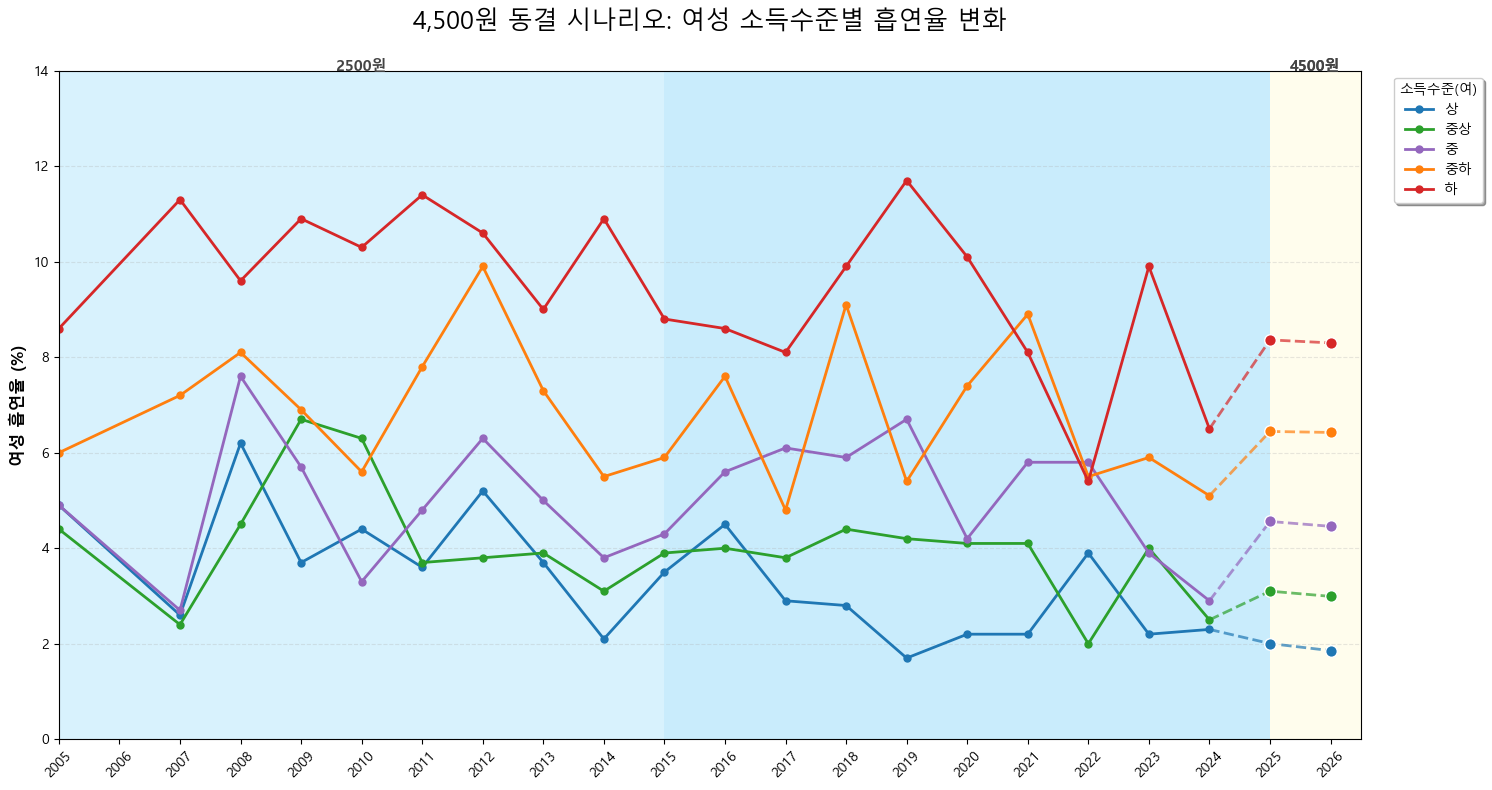

In [8]:
female_income_df = pd.DataFrame({'year': clean_df['year'].unique()}) # year 컬럼 생성

for level in income_levels:
    f_income_row = df[(df[('성별(1)', '성별(1)')] == '여자') & (df[('특성별(2)', '특성별(2)')] == level)]
    
    f_level_rates = []
    for col in df.columns:
        year = col[0]
        sub_col = col[1]
        if '분율 (%)' in sub_col and year.isdigit():
            val = str(f_income_row[col].values[0]).replace('*', '').strip()
            f_level_rates.append(float(val) if val and val != 'nan' else np.nan)
    
    female_income_df[level] = f_level_rates

fig, ax1 = plt.subplots(figsize=(15, 8))

for start, end, price, bg_color in price_regions:
    ax1.axvspan(start, end, facecolor=bg_color, alpha=0.3)
    if price == smoke_money:
        ax1.text(2025.75, 14, f'{price}원', ha='center', fontweight='bold', color='#444444', fontsize=11)
    else:
        ax1.text((start + end) / 2, 14, f'{price}원', ha='center', fontweight='bold', color='#444444', fontsize=11)

last_year = female_income_df['year'].iloc[-1]
lines = []

for level, line_color in zip(income_levels, colors):
    y_vals = female_income_df[level].dropna()
    current_X_scaled = X_scaled[:len(y_vals)] 
    model_f_lvl = LinearRegression().fit(current_X_scaled, y_vals)
    preds = np.maximum(0, model_f_lvl.predict(future_scaled))
    
    plot_years = [last_year] + future_years
    plot_values = [female_income_df[level].iloc[-1]] + list(preds)

    line, = ax1.plot(female_income_df['year'], female_income_df[level], marker='o', label=level, 
                     color=line_color, linewidth=2, markersize=5)
    lines.append(line)

    ax1.plot(plot_years, plot_values, color=line_color, linestyle='--', linewidth=2, alpha=0.7)

    ax1.scatter(future_years, preds, color=line_color, s=70, zorder=5, edgecolors='white')

plt.title(scenario_title + ' 시나리오: 여성 소득수준별 흡연율 변화', fontsize=18, pad=30)
ax1.set_xlim(2005, 2026.5)
ax1.set_xticks(np.arange(2005, 2027, 1))
plt.setp(ax1.get_xticklabels(), rotation=45)

ax1.set_ylim(0, 14)
ax1.set_ylabel('여성 흡연율 (%)', fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

ax1.legend(lines, income_levels, title='소득수준(여)', loc='upper left', bbox_to_anchor=(1.02, 1), 
           frameon=True, shadow=True)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd

income_mapping = {
    '상': ['상'],
    '중': ['중상', '중'],
    '하': ['중하', '하']
}

for label, levels in income_mapping.items():
    all_years_data = []

    for col in df.columns:
        year = col[0]
        sub_col = col[1]
        
        if '분율 (%)' in sub_col and year.isdigit():
            rows = df[df[('특성별(2)', '특성별(2)')].isin(levels)]

            vals = []
            for v in rows[col].values:
                clean_v = str(v).replace('*', '').strip()
                if clean_v and clean_v != 'nan':
                    vals.append(float(clean_v))

            if vals:
                all_years_data.append(np.mean(vals))
            else:
                all_years_data.append(np.nan)

    clean_df[label] = all_years_data

male_3tier_df = pd.DataFrame({'year': clean_df['year'].unique()})
female_3tier_df = pd.DataFrame({'year': clean_df['year'].unique()})

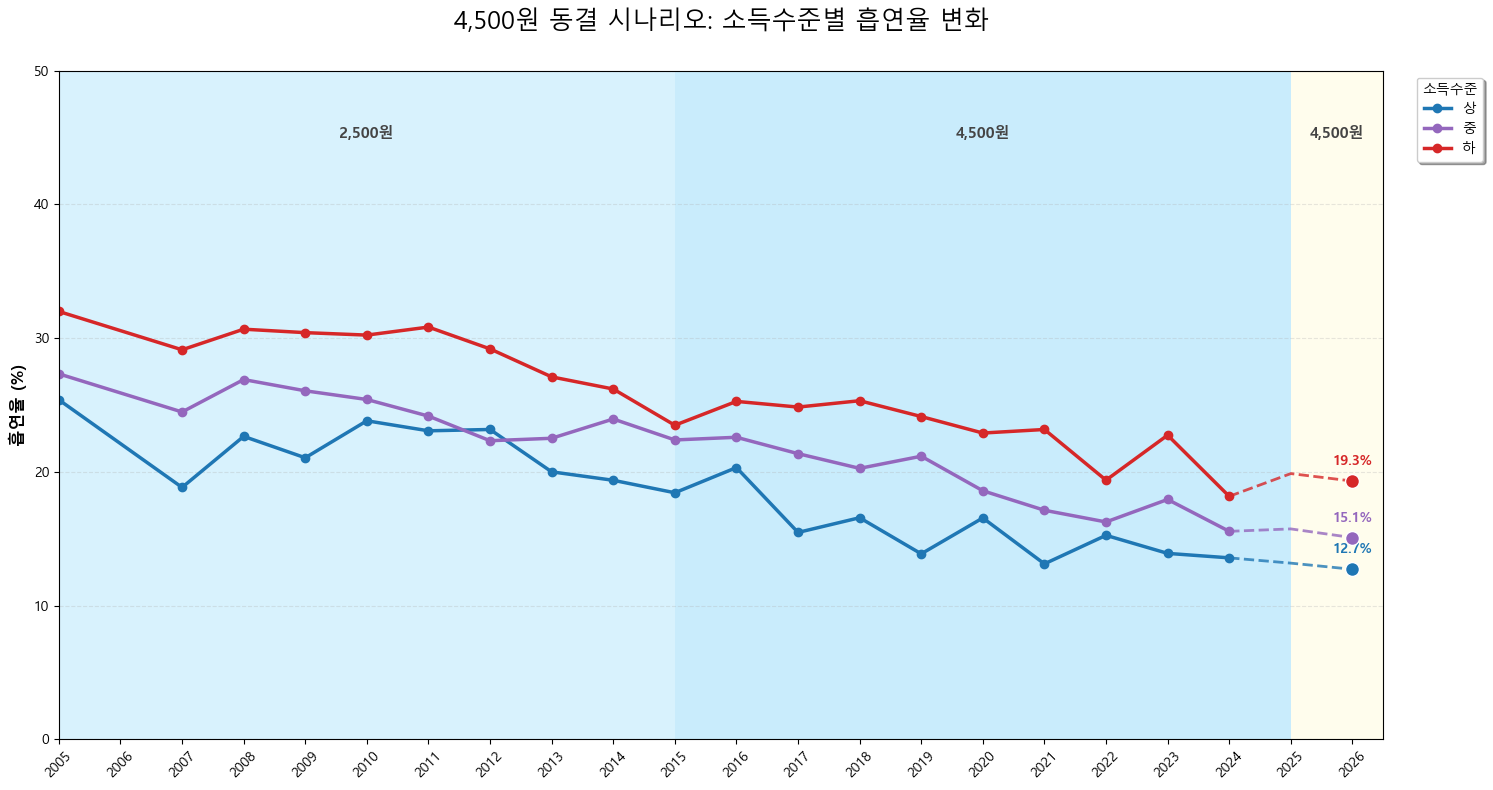


[소득 계층별 모델 결정계수(R^2) 결과]
소득수준 [상 ] 계층 R^2 : 0.7945
소득수준 [중 ] 계층 R^2 : 0.9103
소득수준 [하 ] 계층 R^2 : 0.8864


In [10]:
income_mapping = {
    '상': ['상'],
    '중': ['중상', '중'],
    '하': ['중하', '하']
}
income_labels = list(income_mapping.keys())
new_colors = ['#1f77b4', '#9467bd', '#d62728']

for label, levels in income_mapping.items():
    tier_rates = []
    for col in df.columns:
        year = col[0]
        sub_col = col[1]
        if '분율 (%)' in sub_col and year.isdigit():
            rows = df[df[('특성별(2)', '특성별(2)')].isin(levels)]

            vals = [float(str(v).replace('*', '').strip()) for v in rows[col].values 
                    if str(v).replace('*', '').strip() and str(v) != 'nan']
            tier_rates.append(np.mean(vals) if vals else np.nan)
    
    clean_df[label] = tier_rates

fig, ax1 = plt.subplots(figsize=(15, 8))

for i, (start, end, price, bg_color) in enumerate(price_regions):
    ax1.axvspan(start, end, facecolor=bg_color, alpha=0.3)

    if i == len(price_regions) - 1:
        text_x = 2025.75
    else:
        text_x = (start + end) / 2

    ax1.text(text_x, 45, f'{price:,}원', ha='center', fontweight='bold', color='#444444', fontsize=11)

last_year = clean_df['year'].iloc[-1]
lines = []

for label, line_color in zip(income_labels, new_colors):
    y_vals = clean_df[label].dropna()
    current_X_scaled = X_scaled[:len(y_vals)]
    
    model_lvl = LinearRegression().fit(current_X_scaled, y_vals)
    preds = np.maximum(0, model_lvl.predict(future_scaled))

    plot_years = [last_year] + future_years
    plot_values = [clean_df[label].iloc[-1]] + list(preds)

    line, = ax1.plot(clean_df['year'], clean_df[label], marker='o', label=label, 
                     color=line_color, linewidth=2.5, markersize=6)
    lines.append(line)

    ax1.plot(plot_years, plot_values, color=line_color, linestyle='--', linewidth=2, alpha=0.8)

    ax1.scatter(future_years[1], preds[1], color=line_color, s=100, zorder=5, edgecolors='white')
    ax1.text(2026, preds[1] + 1.2, f'{preds[1]:.1f}%', ha='center', color=line_color, fontweight='bold')

plt.title(f'{scenario_title} 시나리오: 소득수준별 흡연율 변화', fontsize=18, pad=30)
ax1.set_xlim(2005, 2026.5)
ax1.set_xticks(np.arange(2005, 2027, 1))
plt.setp(ax1.get_xticklabels(), rotation=45)

ax1.set_ylim(0, 50)
ax1.set_ylabel('흡연율 (%)', fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

# 범례 설정
ax1.legend(lines, income_labels, title='소득수준', loc='upper left', bbox_to_anchor=(1.02, 1), 
           frameon=True, shadow=True)

plt.tight_layout()
plt.show()

from sklearn.metrics import r2_score

print("\n[소득 계층별 모델 결정계수(R^2) 결과]")
print("=" * 40)

r2_results = {}
for label in income_labels:
    # 1. 해당 소득 계층 데이터 추출
    y_vals = clean_df[label].dropna()
    curr_X = X_scaled[:len(y_vals)]
    
    # 2. 계층별 전용 선형 회귀 학습
    m_lvl = LinearRegression().fit(curr_X, y_vals)
    
    # 3. R2 점수 계산
    r2_val = r2_score(y_vals, m_lvl.predict(curr_X))
    r2_results[label] = r2_val
    
    print(f"소득수준 [{label:^2}] 계층 R^2 : {r2_val:.4f}")

print("=" * 40)

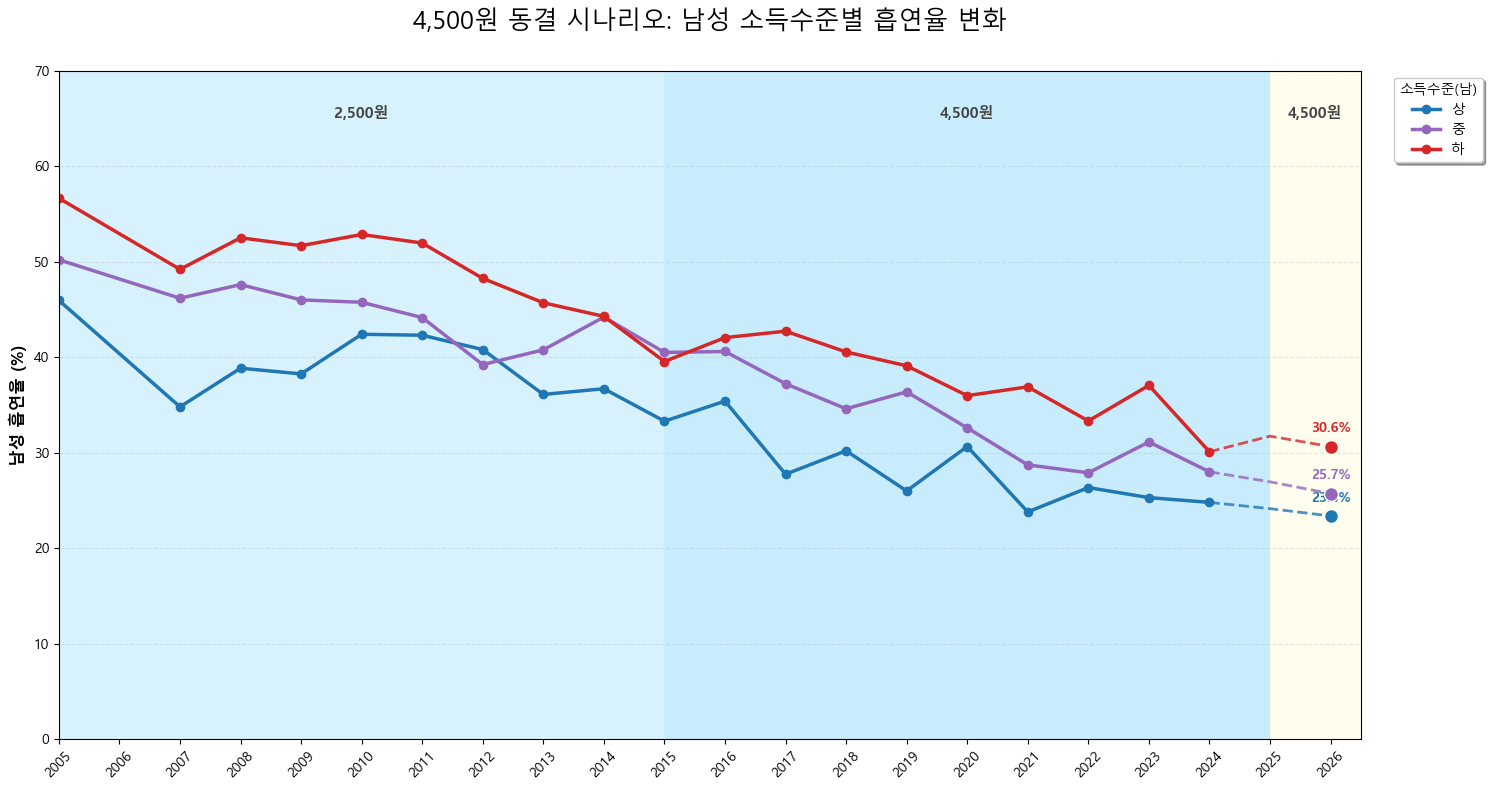


[남성 소득 계층별 모델 결정계수(R^2) 결과]
남성 소득수준 [상 ] 계층 R^2 : 0.8207
남성 소득수준 [중 ] 계층 R^2 : 0.9215
남성 소득수준 [하 ] 계층 R^2 : 0.9231


In [11]:
income_labels = list(income_mapping.keys())
new_colors = ['#1f77b4', '#9467bd', '#d62728'] 

for label, levels in income_mapping.items():
    tier_rates = []
    for col in df.columns:
        year = col[0]
        sub_col = col[1]
        if '분율 (%)' in sub_col and year.isdigit():
            rows = df[(df[('성별(1)', '성별(1)')] == '남자') & 
                      (df[('특성별(2)', '특성별(2)')].isin(levels))]

            vals = [float(str(v).replace('*', '').strip()) for v in rows[col].values 
                    if str(v).replace('*', '').strip() and str(v) != 'nan']
            tier_rates.append(np.mean(vals) if vals else np.nan)

    male_3tier_df[label] = tier_rates

fig, ax1 = plt.subplots(figsize=(15, 8))

for i, (start, end, price, bg_color) in enumerate(price_regions):
    ax1.axvspan(start, end, facecolor=bg_color, alpha=0.3)

    if i == len(price_regions) - 1:
        text_x = 2025.75
    else:
        text_x = (start + end) / 2
        
    ax1.text(text_x, 65, f'{price:,}원', ha='center', fontweight='bold', color='#444444', fontsize=11)

last_year = male_3tier_df['year'].iloc[-1]
lines = []

for label, line_color in zip(income_labels, new_colors):
    y_vals = male_3tier_df[label].dropna()
    current_X_scaled = X_scaled[:len(y_vals)] 
    
    model_m_3tier = LinearRegression().fit(current_X_scaled, y_vals)
    preds = np.maximum(0, model_m_3tier.predict(future_scaled))
    
    plot_years = [last_year] + future_years
    plot_values = [male_3tier_df[label].iloc[-1]] + list(preds)

    line, = ax1.plot(male_3tier_df['year'], male_3tier_df[label], marker='o', label=label, 
                     color=line_color, linewidth=2.5, markersize=6)
    lines.append(line)
    ax1.plot(plot_years, plot_values, color=line_color, linestyle='--', linewidth=2, alpha=0.8)

    ax1.scatter(future_years[1], preds[1], color=line_color, s=100, zorder=5, edgecolors='white')
    ax1.text(2026, preds[1] + 1.5, f'{preds[1]:.1f}%', ha='center', color=line_color, fontweight='bold')

plt.title(f'{scenario_title} 시나리오: 남성 소득수준별 흡연율 변화', fontsize=18, pad=30)
ax1.set_xlim(2005, 2026.5)
ax1.set_xticks(np.arange(2005, 2027, 1))
plt.setp(ax1.get_xticklabels(), rotation=45)

ax1.set_ylim(0, 70)
ax1.set_ylabel('남성 흡연율 (%)', fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

ax1.legend(lines, income_labels, title='소득수준(남)', loc='upper left', bbox_to_anchor=(1.02, 1), 
           frameon=True, shadow=True)

plt.tight_layout()
plt.show()

from sklearn.metrics import r2_score

print("\n[남성 소득 계층별 모델 결정계수(R^2) 결과]")
print("=" * 45)

male_r2_results = {}
for label in income_labels:
    y_vals_m = male_3tier_df[label].dropna()
    curr_X_m = X_scaled[:len(y_vals_m)]

    m_lvl_male = LinearRegression().fit(curr_X_m, y_vals_m)

    r2_val_m = r2_score(y_vals_m, m_lvl_male.predict(curr_X_m))
    male_r2_results[label] = r2_val_m
    
    print(f"남성 소득수준 [{label:^2}] 계층 R^2 : {r2_val_m:.4f}")

print("=" * 45)

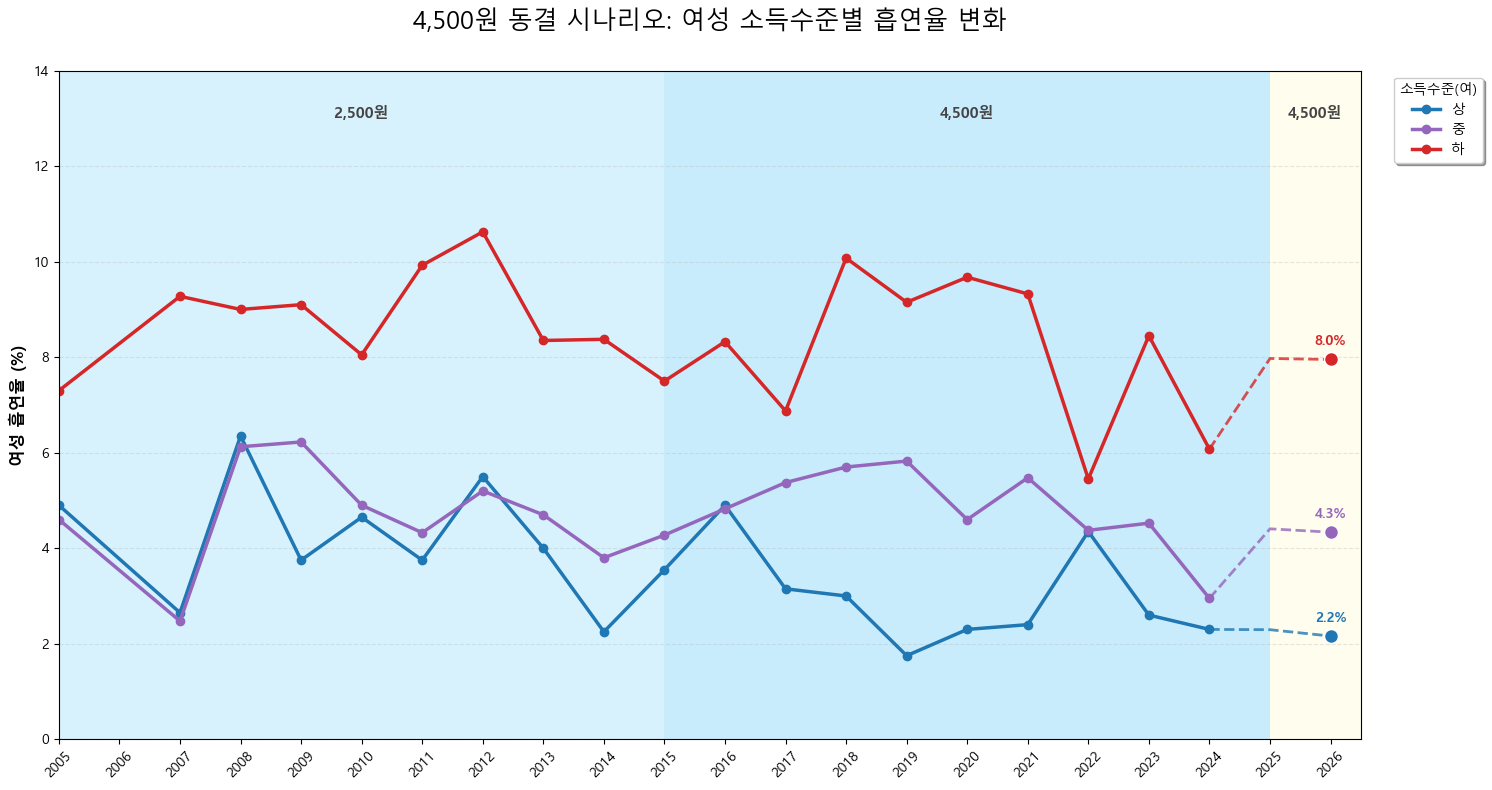


[여성 소득 계층별 모델 결정계수(R^2) 결과]
여성 소득수준 [상 ] 계층 R^2 : 0.3175
여성 소득수준 [중 ] 계층 R^2 : 0.0454
여성 소득수준 [하 ] 계층 R^2 : 0.0930


In [12]:
income_labels = list(income_mapping.keys())
new_colors = ['#1f77b4', '#9467bd', '#d62728'] 

female_3tier_df = pd.DataFrame({'year': clean_df['year'].unique()})

for label, levels in income_mapping.items():
    tier_rates = []
    for col in df.columns:
        year = col[0]
        sub_col = col[1]
        if '분율 (%)' in sub_col and year.isdigit():
            rows = df[(df[('성별(1)', '성별(1)')] == '여자') & 
                      (df[('특성별(2)', '특성별(2)')].isin(levels))]

            vals = [float(str(v).replace('*', '').strip()) for v in rows[col].values 
                    if str(v).replace('*', '').strip() and str(v) != 'nan']
            tier_rates.append(np.mean(vals) if vals else np.nan)

    female_3tier_df[label] = tier_rates

fig, ax1 = plt.subplots(figsize=(15, 8))

for i, (start, end, price, bg_color) in enumerate(price_regions):
    ax1.axvspan(start, end, facecolor=bg_color, alpha=0.3)

    if i == len(price_regions) - 1:
        text_x = 2025.75
    else:
        text_x = (start + end) / 2

    ax1.text(text_x, 13, f'{price:,}원', ha='center', fontweight='bold', color='#444444', fontsize=11)

last_year = female_3tier_df['year'].iloc[-1]
lines = []

for label, line_color in zip(income_labels, new_colors):
    y_vals = female_3tier_df[label].dropna()
    current_X_scaled = X_scaled[:len(y_vals)] 
    
    model_f_3tier = LinearRegression().fit(current_X_scaled, y_vals)
    preds = np.maximum(0, model_f_3tier.predict(future_scaled))
    
    plot_years = [last_year] + future_years
    plot_values = [female_3tier_df[label].iloc[-1]] + list(preds)

    line, = ax1.plot(female_3tier_df['year'], female_3tier_df[label], marker='o', label=label, 
                     color=line_color, linewidth=2.5, markersize=6)
    lines.append(line)

    ax1.plot(plot_years, plot_values, color=line_color, linestyle='--', linewidth=2, alpha=0.8)

    ax1.scatter(future_years[1], preds[1], color=line_color, s=100, zorder=5, edgecolors='white')
    ax1.text(2026, preds[1] + 0.3, f'{preds[1]:.1f}%', ha='center', color=line_color, fontweight='bold', fontsize=10)

plt.title(f'{scenario_title} 시나리오: 여성 소득수준별 흡연율 변화', fontsize=18, pad=30)
ax1.set_xlim(2005, 2026.5)
ax1.set_xticks(np.arange(2005, 2027, 1))
plt.setp(ax1.get_xticklabels(), rotation=45)

ax1.set_ylim(0, 14) 
ax1.set_ylabel('여성 흡연율 (%)', fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

ax1.legend(lines, income_labels, title='소득수준(여)', loc='upper left', bbox_to_anchor=(1.02, 1), 
           frameon=True, shadow=True)

plt.tight_layout()
plt.show()

from sklearn.metrics import r2_score

print("\n[여성 소득 계층별 모델 결정계수(R^2) 결과]")
print("=" * 45)

female_r2_results = {}
for label in income_labels:
    y_vals_f = female_3tier_df[label].dropna()
    curr_X_f = X_scaled[:len(y_vals_f)]

    m_lvl_female = LinearRegression().fit(curr_X_f, y_vals_f)
    
    # 3. R2 점수 계산
    r2_val_f = r2_score(y_vals_f, m_lvl_female.predict(curr_X_f))
    female_r2_results[label] = r2_val_f
    
    print(f"여성 소득수준 [{label:^2}] 계층 R^2 : {r2_val_f:.4f}")

print("=" * 45)

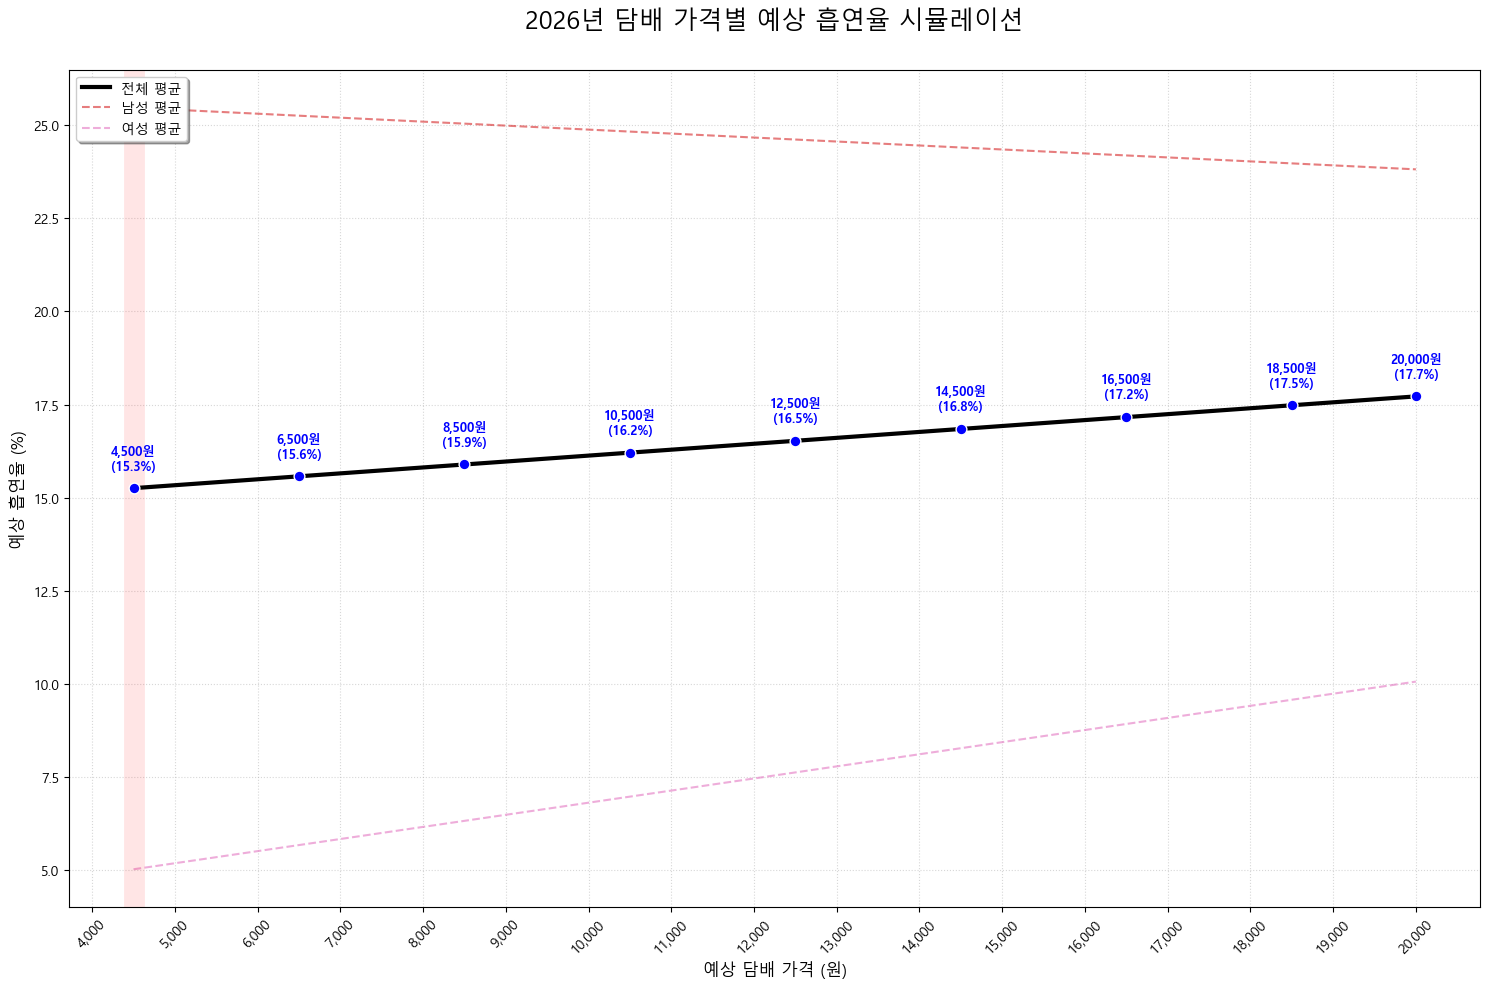

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

years_list = np.arange(2005, 2025)
income_levels = ['상', '중상', '중', '중하', '하']

def get_total_avg_data(gender_filter=None):
    all_years_avg = []
    for year in years_list:
        col_name = str(year)
        target_col = [c for c in df.columns if c[0] == col_name and '분율 (%)' in c[1]]
        if not target_col:
            all_years_avg.append(np.nan)
            continue

        if gender_filter:
            condition = (df[('성별(1)', '성별(1)')] == gender_filter) & \
                        (df[('특성별(2)', '특성별(2)')].isin(income_levels))
        else:
            condition = (df[('특성별(2)', '특성별(2)')].isin(income_levels))
        
        rows = df[condition]
        vals = [float(str(v).replace('*', '').strip()) for v in rows[target_col[0]].values 
                if str(v).replace('*', '').strip() and str(v) != 'nan']
        all_years_avg.append(np.mean(vals) if vals else np.nan)
    return pd.Series(all_years_avg)

t_avg = get_total_avg_data(None)
m_avg = get_total_avg_data('남자')
f_avg = get_total_avg_data('여자')

prices_list = [2500]*10 + [4500]*10
X_raw = np.column_stack([years_list, prices_list])
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(X_raw)

def final_predict_logic(y_series, target_price):
    y_vals = y_series.dropna().values
    curr_X = X_scaled_final[:len(y_vals)]
    model = LinearRegression().fit(curr_X, y_vals)
    input_df = pd.DataFrame([[2026, target_price]], columns=['year', 'smoke_money'])
    input_scaled = scaler_final.transform(input_df)
    return max(0, model.predict(input_scaled)[0])

fine_test_prices = np.arange(4500, 20001, 100)
t_preds = [final_predict_logic(t_avg, p) for p in fine_test_prices]
m_preds = [final_predict_logic(m_avg, p) for p in fine_test_prices]
f_preds = [final_predict_logic(f_avg, p) for p in fine_test_prices]

plt.figure(figsize=(15, 10))

# 메인 라인
plt.plot(fine_test_prices, t_preds, label='전체 평균', color='black', linewidth=3, zorder=3)
plt.plot(fine_test_prices, m_preds, label='남성 평균', color='#d62728', linestyle='--', alpha=0.6)
plt.plot(fine_test_prices, f_preds, label='여성 평균', color='#e377c2', linestyle='--', alpha=0.6)

check_points = list(range(4500, 20001, 2000)) + [20000]
for p in check_points:
    idx = (np.abs(fine_test_prices - p)).argmin()
    val = t_preds[idx]
    plt.scatter(p, val, color='blue', s=60, edgecolors='white', zorder=5)
    plt.text(p, val + 0.5, f'{p:,}원\n({val:.1f}%)', ha='center', fontsize=9, color='blue', fontweight='bold')

plt.title('2026년 담배 가격별 예상 흡연율 시뮬레이션', fontsize=18, pad=30)
plt.xlabel('예상 담배 가격 (원)', fontsize=12)
plt.ylabel('예상 흡연율 (%)', fontsize=12)
plt.xticks(np.arange(4000, 21000, 1000), [f'{x:,}' for x in np.arange(4000, 21000, 1000)], rotation=45)
plt.grid(True, linestyle=':', alpha=0.5)
plt.axvline(x=4500, color='red', linestyle='-', alpha=0.1, linewidth=15)
plt.legend(shadow=True, loc='upper left')

plt.tight_layout()
plt.show()